# Laboratório 3 – Avaliando o desempenho

**Disciplina:** Programação Concorrente (ICP-361)

🎯 **Objetivos de aprendizagem**:
- Avaliar o tempo de execução de um programa.
- Implementar uma versão paralela e avaliar ganho, eficiência e escalabilidade.


⚠️ *Observação*: o Colab não é ideal para benchmarks precisos, mas é adequado para fins didáticos.

## 1. Preparação do ambiente

Para que essa tomada de tempo seja realizada de forma correta, precisamos usar
funções que meçam o tempo de forma contínua, isto é, sem a interferência de alterações ou ajustes no relógio do sistema. Em ambientes Linux, por exemplo, podemos calcular o tempo de execução de um trecho de um programa escrito em C usando a função `clock_gettime()`, definida na biblioteca `time.h`. Essa função retorna uma estrutura de dados que contém dois campos: um contador de segundos e um contador de nanosegundos cujos valores são preenchidos com o tempo transcorrido desde um momento predefinido no passado.

Para obter o tempo total em segundos como um número decimal (ponto flutuante), usamos a fórmula que você aplicou no seu código:

$$TempoTotal = tv\_sec + \frac{tv\_nsec}{10^9}$$

O primeiro argumento da função define qual relógio você quer ler. Isso é crucial para o seu programa de produto interno:

- CLOCK_REALTIME: É o relógio "de parede" (System Time). Ele representa o tempo real do calendário. Problema: Se o usuário ou um protocolo NTP ajustar a hora do sistema durante a execução, sua medição de tempo ficará errada.

- CLOCK_MONOTONIC: Um relógio que avança de forma constante a partir de um ponto de início arbitrário (geralmente o *boot* do sistema). Ele não pode sofrer saltos para trás, sendo ideal para medir intervalos de tempo.

- CLOCK_MONOTONIC_RAW: Semelhante ao monotonic, mas fornece acesso direto ao *hardware* de tempo sem passar pelos ajustes de frequência que o kernel faz para sincronizar o relógio. É o mais puro para *benchmarking* de código.

- CLOCK_PROCESS_CPUTIME_ID: Mede apenas o tempo que a CPU passou executando o seu processo. Se o processo for interrompido pelo sistema, o relógio para.

O código abaixo mostra um exemplo de uso da função `clock_gettime()` para calcular o tempo gasto para executar um determinado trecho do programa. A função auxiliar `tempoAtual` chama a função `clock_gettime()` e em seguida processa a estrutura de dados retornada para gerar uma medida de tempo em segundos.

In [8]:
%%writefile mede_tempo.c
#include <time.h>
#include <stdio.h>
//retorna o instante de tempo atual em segundos
double tempoAtual() {
struct timespec tempo;
clock_gettime(CLOCK_MONOTONIC_RAW, &tempo);
return tempo.tv_sec + tempo.tv_nsec/1000000000.0;
}

void main() {
double inicio, fim, delta, temp;
inicio = tempoAtual();
for (int i = 0; i< 100000; i++)
  for (int j = 0; j< 100000; j++)
       temp = (double) i*j;
//...trecho do programa que queremos medir o tempo
fim = tempoAtual();
//tempo consumido para executar o trecho do programa
delta = fim - inicio;
printf("O tempo de execução foi de %f segundos\n", delta);
}

Overwriting mede_tempo.c


In [9]:
!gcc -o teste mede_tempo.c
!./teste

O tempo de execução foi de 8.045569 segundos


Normalmente, quando já dispomos de uma implementação sequencial do problema e queremos paralelizá-la, o primeiro passo consiste em identificar quais partes do programa demandam maior tempo de execução e então avaliar as possibilidades de paralelização dessas partes.

## 2. Atividade 1 – Verificar o tempo de execução de um programa sequemcial

### Objetivo:

Executar o código sequencial de cálculo de produto interno a seguir e verificar o tempo de execução sequencial.

### Descrição:

Sejam ($a_1 , a_2 , . . . , a_N )^T$ e $(b_1 , b_2 , . . . , b_N )^T$ vetores em um espaço de dimensão $N$ expressos em termos de um sistema ortogonal de coordenadas cartesianas.

O produto interno desses dois vetores é um valor real dado pela equação: $a_1 \cdot b_1 + a_2 \cdot b_2 + . . . + a_N \cdot b_N$

In [10]:
%%writefile prod_int.c

#include <stdio.h>
#include <stdlib.h>
#include <time.h>

#define TAMANHO 100000000 // 100 milhoes de elementos
#define VEZES 100 // Número de vezes que o cálculo será repetido

// Rotina para medir o tempo fornecida
double tempoAtual() {
    struct timespec tempo;
    clock_gettime(CLOCK_MONOTONIC_RAW, &tempo);
    return tempo.tv_sec + tempo.tv_nsec / 1000000000.0;
}

int main() {
    // 1. Alocação de memória para os vetores
    double *vecA = (double *)malloc(TAMANHO * sizeof(double));
    double *vecB = (double *)malloc(TAMANHO * sizeof(double));
    double resultado = 0.0;
    double resultadoVerificacao = 0.0;

    if (vecA == NULL || vecB == NULL) {
        printf("Erro ao alocar memória.\n");
        return 1;
    }

    // 2. Inicialização dos vetores
    // Usaremos valores previsíveis para facilitar a verificação:
    // vecA[i] = 1.0 e vecB[i] = 2.0. O produto interno deve ser TAMANHO * 2.0
    for (int i = 0; i < TAMANHO; i++) {
         vecA[i] = 1.0;
         vecB[i] = 2.0;
    }

    printf("Iniciando cálculo para %d elementos...\n", TAMANHO);

    // 3. Medição e Cálculo do Produto Interno
    double inicio = tempoAtual();
    // Para aumentar o tempo total de execução do programa
    for(int j = 0; j < VEZES; j++) {
        resultado = 0.0;
        for (int i = 0; i < TAMANHO; i++)
            resultado += vecA[i] * vecB[i];
    }

    double fim = tempoAtual();

    // 4. Verificação do resultado
    // Como sabemos que 1.0 * 2.0 = 2.0, a soma total deve ser 2.0 * TAMANHO
    double esperado = (double)TAMANHO * 2.0;

    printf("--- Resultados ---\n");
    printf("Tempo de Execução: %.6f segundos\n", fim - inicio);
    printf("Resultado Obtido:  %.2f\n", resultado);
    printf("Resultado Esperado: %.2f\n", esperado);

    if (resultado == esperado) {
        printf("Verificação: SUCESSO (O resultado está correto).\n");
    } else {
        printf("Verificação: FALHA (Diferença detectada).\n");
    }

    // Limpeza
    free(vecA);
    free(vecB);

    return 0;
}


Overwriting prod_int.c


In [11]:
!gcc -o teste prod_int.c
!./teste

Iniciando cálculo para 100000000 elementos...
--- Resultados ---
Tempo de Execução: 37.508574 segundos
Resultado Obtido:  200000000.00
Resultado Esperado: 200000000.00
Verificação: SUCESSO (O resultado está correto).


In [12]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 25
model		: 1
model name	: AMD EPYC 7B13
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2449.998
cache size	: 512 KB
physical id	: 0
siblings	: 24
core id		: 0
cpu cores	: 12
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl nonstop_tsc cpuid extd_apicid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm cmp_legacy cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw topoext ssbd ibrs ibpb stibp vmmcall fsgsbase tsc_adjust bmi1 avx2 smep bmi2 erms invpcid rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 clzero xsaveerptr arat npt nrip_save umip vaes vpclmulqdq rdpid fsrm
bugs		: sysret_ss_attrs null_seg spectre_v1 spectre_v2 spec

## 3. Atividade 2 – Versão paralela com uso de pthreads.

### Objetivo:

Escrever uma versão paralela do cálculo de produto interno e verificar o tempo de execução com quatro threads.





In [17]:
%%writefile prod_int_par.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <pthread.h>

#define TAMANHO 100000000 // 100 milhoes de elementos
#define VEZES 100 // Número de vezes que o cálculo será repetido
#define NUM_THREADS 4 // Define o número de threads

// Estrutura para passar dados para as threads
typedef struct {
    double *vecA;
    double *vecB;
    int inicio;
    int fim;
    double resultado_parcial;
} ThreadData;

double tempoAtual() {
    struct timespec tempo;
    clock_gettime(CLOCK_MONOTONIC_RAW, &tempo);
    return tempo.tv_sec + tempo.tv_nsec / 1000000000.0;
}

void *calcula_produto_interno(void *arg) {
    ThreadData *data = (ThreadData *)arg;
    register double temp;
    for(int j = 0; j<VEZES; j++){
      temp = 0.0;
      for (int i = data->inicio; i < data->fim; i++) {
        temp += data->vecA[i] * data->vecB[i];
      }
    }
    data->resultado_parcial = temp;
    pthread_exit(NULL);
}

int main() {
    // 1. Alocação de memória para os vetores
    double *vecA = (double *)malloc(TAMANHO * sizeof(double));
    double *vecB = (double *)malloc(TAMANHO * sizeof(double));
    double resultado = 0.0;
    double resultadoVerificacao = 0.0;
    double inicio, fim, tempo_paralelo;
    double tempo_sequencial = 37.430560; // Valor obtido na Atividade 1
    pthread_t tids[NUM_THREADS];
    ThreadData *args = (ThreadData *)malloc(NUM_THREADS * sizeof(ThreadData));



    if (vecA == NULL || vecB == NULL) {
        printf("Erro ao alocar memória.\n");
        return 1;
    }

    // 2. Inicialização dos vetores
    // Usaremos valores previsíveis para facilitar a verificação:
    // vecA[i] = 1.0 e vecB[i] = 2.0. O produto interno deve ser TAMANHO * 2.0
    for (int i = 0; i < TAMANHO; i++) {
         vecA[i] = 1.0;
         vecB[i] = 2.0;
    }

    printf("Iniciando cálculo para %d elementos...\n", TAMANHO);

    // 3. Medição e Cálculo do Produto Interno
    inicio = tempoAtual();

    // Criar as threads e atribuir os parãmetros iniciais
    for (int i = 0; i < NUM_THREADS; i++) {
      args[i].vecA = vecA;
      args[i].vecB = vecB;
      args[i].inicio = i * (TAMANHO / NUM_THREADS);
      args[i].fim = (i == NUM_THREADS -1 )? TAMANHO : (i + 1) * (TAMANHO / NUM_THREADS);

      if (pthread_create(&tids[i], NULL, calcula_produto_interno, (void *)&args[i])){
        printf("Erro ao criar a thread %d\n", i);
        return 1;
      }
    }

    // Esperar pelo término das threads
    for (int i = 0; i < NUM_THREADS; i++) {
      if (pthread_join(tids[i], NULL)){
        printf("Erro ao juntar a thread %d\n", i);
        return 1;
      }
      resultado += args[i].resultado_parcial;
    }
    free(args);

    fim = tempoAtual();
    tempo_paralelo = fim - inicio;

    // 4. Verificação do resultado
    // Como sabemos que 1.0 * 2.0 = 2.0, a soma total deve ser 2.0 * TAMANHO
    double esperado = (double)TAMANHO * 2.0;
    double speedup = tempo_sequencial / tempo_paralelo;
    double eficiencia = speedup / NUM_THREADS;

    printf("--- Resultados ---\n");
    printf("Tempo de Execução: %.6f segundos\n", fim - inicio);
    printf("Resultado Obtido:  %.2f\n", resultado);
    printf("Resultado Esperado: %.2f\n", esperado);
    printf("Speedup Obtido:         %.2f\n", speedup);
    printf("Eficiencia:             %.2f (%.1f%%)\n", eficiencia, eficiencia * 100);

    if (resultado == esperado) {
        printf("Verificação: SUCESSO (O resultado está correto).\n");
    } else {
        printf("Verificação: FALHA (Diferença detectada).\n");
    }

    // Limpeza
    free(vecA);
    free(vecB);

    return 0;
}



Overwriting prod_int_par.c


In [18]:
!gcc -o teste prod_int_par.c -pthread
!./teste

Iniciando cálculo para 100000000 elementos...
--- Resultados ---
Tempo de Execução: 4.600950 segundos
Resultado Obtido:  200000000.00
Resultado Esperado: 200000000.00
Speedup Obtido:         8.14
Eficiencia:             2.03 (203.4%)
Verificação: SUCESSO (O resultado está correto).


## 3. Atividade 3 – Avaliar o resultado obtido

### Responda às seguintes perguntas e realize as atividades propostas

- Qual foi o tempo de execução com 4 threads?

R: 4.613399 segundos

- O resultado ficou dentro do esperado?
Como visto em sala, a rapidez foi motivada pelo uso de `register` em `register double temp;`, evistando o estouro de memória em cache L3, evitando puxar a linha toda a cada iteração, e realizando o acesso uma unica vez.

- Quais a possíveis causas para o resultado obtido?
  - O balanceamento de carga foi realizado adequadamente?

R: Foi realizado de forma estática por blocos. Como cada thread processa exatamente a mesma quantidade de elementos ($N/M$), o balanceamento é ideal para essa tarefa homogênea.
  
  - Os processadores utilizados são de igual capacidade?

  R: O ambiente do Colab utilizou uma CPU AMD EPYC 7B13 com 12 núcleos físicos e 24 threads (siblings). Como todos os núcleos pertencem ao mesmo processador, eles têm capacidades iguais
  
  - Há alguma sincronização que possa ser um ponto de congestionamento?
  
  R: O código quase não possui pontos de congestionamento, pois não utiliza mutexes ou variáveis de condição dentro dos loops. Cada thread trabalha em seu próprio espaço de memória (resultado_parcial), havendo sincronização apenas no final com o `pthread_join`


- Modifique o código proposto e fique iterando até os resultados serem satisfatórios e então responda:

R: Tempo Sequencial ($T_s$): 37.43s | Tempo Paralelo ($T_p$): 4.61s | Número de Processadores ($n$): 4
  - Qual foi o speedup obtido?
  
  R: Speedup Obtido:         8.14
  - Qual a eficiência obtida?

  R: Eficiencia:             2.03 (203.4%)
- Trace o gráfico de tempo de execução, *speedup* e eficiência do código otimimzado executando com 2, 4, 6 e 8 threads.
- Escreva uma versão que faça a distribuição alternada do vetor entre as threads.
  - Execute o programa com 4 threads.
  - O desempenho foi melhor ou pior?

  R: O desempenho na distribuição alternada foi significativamente pior.

Tempo: O tempo saltou de 4,60 segundos (bloco) para 7,55 segundos (alternada).

Eficiência: A eficiência caiu de 203,4% para 123,9%.

Speedup: Houve uma redução na aceleração de 8,14 para 4,95.
  - Quais as possíveis explicações para isso

  R: False Sharing, Localidade Espacial e Cache Lines


Threads    | Tempo (s)    | Speedup    | Eficiência
--------------------------------------------------
2          | 4.902200     | 7.6355     | 3.8177    
4          | 2.833168     | 13.2116    | 3.3029    
6          | 3.425305     | 10.9277    | 1.8213    
8          | 4.082521     | 9.1685     | 1.1461    


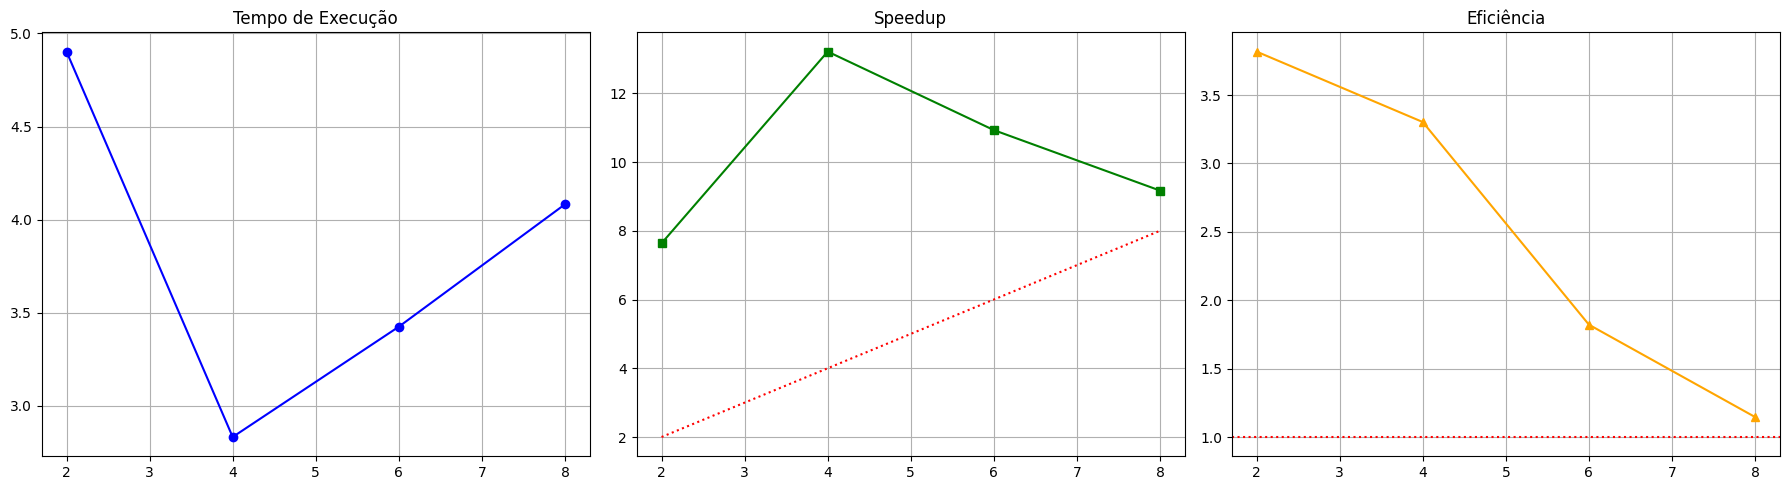

In [20]:
import subprocess
import matplotlib.pyplot as plt
import re

# Configurações do experimento
THREADS_LIST = [2, 4, 6, 8]
T_SEQUENCIAL = 37.430560  # Base obtida na Atividade 1
C_FILE = "prod_int_par.c"
EXEC_FILE = "./teste_benchmark"

tempos = []
speedups = []
eficiencias = []

print(f"{'Threads':<10} | {'Tempo (s)':<12} | {'Speedup':<10} | {'Eficiência':<10}")
print("-" * 50)

for m in THREADS_LIST:
    # 1. Modifica o NUM_THREADS no arquivo .c via sed
    subprocess.run(["sed", "-i", f"s/#define NUM_THREADS [0-9]*/#define NUM_THREADS {m}/", C_FILE])

    # 2. Compila com otimização máxima
    compilacao = subprocess.run(["gcc", "-O3", "-o", EXEC_FILE, C_FILE, "-pthread"], capture_output=True, text=True)
    if compilacao.returncode != 0:
        print(f"Erro na compilação para {m} threads.")
        continue

    # 3. Executa o binário
    resultado = subprocess.run([EXEC_FILE], capture_output=True, text=True)

    # 4. Processamento dos resultados
    match = re.search(r"Tempo de Execução: ([\d.]+) segundos", resultado.stdout)
    if match:
        t_par = float(match.group(1))

        # Cálculos de métricas em tempo real
        s = T_SEQUENCIAL / t_par
        e = s / m

        # Armazenamento para os gráficos
        tempos.append(t_par)
        speedups.append(s)
        eficiencias.append(e)

        # Impressão formatada pedida
        print(f"{m:<10} | {t_par:<12.6f} | {s:<10.4f} | {e:<10.4f}")
    else:
        print(f"Erro ao capturar dados para {m} threads.")

# --- Geração dos Gráficos (Mantida para completar a tarefa) ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(THREADS_LIST, tempos, marker='o', color='blue'); ax[0].set_title('Tempo de Execução'); ax[0].grid(True)
ax[1].plot(THREADS_LIST, speedups, marker='s', color='green'); ax[1].plot(THREADS_LIST, THREADS_LIST, 'r:'); ax[1].set_title('Speedup'); ax[1].grid(True)
ax[2].plot(THREADS_LIST, eficiencias, marker='^', color='orange'); ax[2].axhline(y=1.0, color='red', linestyle=':'); ax[2].set_title('Eficiência'); ax[2].grid(True)
plt.tight_layout()
plt.savefig('analise_detalhada.png')

In [22]:
%%writefile prod_int_par.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>
#include <pthread.h>

#define TAMANHO 100000000 // 100 milhoes de elementos
#define VEZES 100 // Número de vezes que o cálculo será repetido
#define NUM_THREADS 4 // Define o número de threads

// Estrutura para passar dados para as threads
typedef struct {
    double *vecA;
    double *vecB;
    long int idThread;
    long int tam;
    double resultado_parcial;
} ThreadData;

double tempoAtual() {
    struct timespec tempo;
    clock_gettime(CLOCK_MONOTONIC_RAW, &tempo);
    return tempo.tv_sec + tempo.tv_nsec / 1000000000.0;
}

void *calcula_produto_interno(void *arg) {
    ThreadData *data = (ThreadData *)arg;
    register double temp;


    for(int j = 0; j<VEZES; j++){
      temp = 0.0;
      for (int i = data->idThread; i < data->tam; i += NUM_THREADS) {
        temp += data->vecA[i] * data->vecB[i];
      }
    }
    data->resultado_parcial = temp;
    pthread_exit(NULL);
}

int main() {
    // 1. Alocação de memória para os vetores
    double *vecA = (double *)malloc(TAMANHO * sizeof(double));
    double *vecB = (double *)malloc(TAMANHO * sizeof(double));
    double resultado = 0.0;
    double resultadoVerificacao = 0.0;
    double inicio, fim, tempo_paralelo;
    double tempo_sequencial = 37.430560; // Valor obtido na Atividade 1
    pthread_t tids[NUM_THREADS];
    ThreadData *args = (ThreadData *)malloc(NUM_THREADS * sizeof(ThreadData));



    if (vecA == NULL || vecB == NULL) {
        printf("Erro ao alocar memória.\n");
        return 1;
    }

    // 2. Inicialização dos vetores
    // Usaremos valores previsíveis para facilitar a verificação:
    // vecA[i] = 1.0 e vecB[i] = 2.0. O produto interno deve ser TAMANHO * 2.0
    for (int i = 0; i < TAMANHO; i++) {
         vecA[i] = 1.0;
         vecB[i] = 2.0;
    }

    printf("Iniciando cálculo para %d elementos...\n", TAMANHO);

    // 3. Medição e Cálculo do Produto Interno
    inicio = tempoAtual();

    // Criar as threads e atribuir os parãmetros iniciais
    for (int i = 0; i < NUM_THREADS; i++) {
      args[i].vecA = vecA;
      args[i].vecB = vecB;
      args[i].idThread = i;
      args[i].tam = TAMANHO;

      if (pthread_create(&tids[i], NULL, calcula_produto_interno, (void *)&args[i])){
        printf("Erro ao criar a thread %d\n", i);
        return 1;
      }
    }

    // Esperar pelo término das threads
    for (int i = 0; i < NUM_THREADS; i++) {
      if (pthread_join(tids[i], NULL)){
        printf("Erro ao juntar a thread %d\n", i);
        return 1;
      }
      resultado += args[i].resultado_parcial;
    }
    free(args);

    fim = tempoAtual();
    tempo_paralelo = fim - inicio;

    // 4. Verificação do resultado
    // Como sabemos que 1.0 * 2.0 = 2.0, a soma total deve ser 2.0 * TAMANHO
    double esperado = (double)TAMANHO * 2.0;
    double speedup = tempo_sequencial / tempo_paralelo;
    double eficiencia = speedup / NUM_THREADS;

    printf("--- Resultados ---\n");
    printf("Tempo de Execução: %.6f segundos\n", fim - inicio);
    printf("Resultado Obtido:  %.2f\n", resultado);
    printf("Resultado Esperado: %.2f\n", esperado);
    printf("Speedup Obtido:         %.2f\n", speedup);
    printf("Eficiencia:             %.2f (%.1f%%)\n", eficiencia, eficiencia * 100);

    if (resultado == esperado) {
        printf("Verificação: SUCESSO (O resultado está correto).\n");
    } else {
        printf("Verificação: FALHA (Diferença detectada).\n");
    }

    // Limpeza
    free(vecA);
    free(vecB);

    return 0;
}



Overwriting prod_int_par.c


In [23]:
!gcc -o teste prod_int_par.c -pthread
!./teste

Iniciando cálculo para 100000000 elementos...
--- Resultados ---
Tempo de Execução: 7.555110 segundos
Resultado Obtido:  200000000.00
Resultado Esperado: 200000000.00
Speedup Obtido:         4.95
Eficiencia:             1.24 (123.9%)
Verificação: SUCESSO (O resultado está correto).


## 5. Atividade 4 – Entrega do laboratório:

Disponibilize os códigos implementados na Atividade 4 em um ambiente de acesso remoto (GitHub ou GitLab). Use o formulário de entrega desse laboratório para enviar o link do repositório do código implementado e responder as questões propostas.

📦 **Entrega**:
- Disponibilize os códigos no GitHub ou GitLab
- Responda às questões propostas no formulário
